# Solution - Audit and rescue the rent model

Instructor solution. The starter `buggy_rent_model.ipynb` hides **twelve** methodology
bugs (L04-L07). Below: the filled audit table (Part 1), the corrected pipeline
(Part 2), and the honest model + model card (Part 3).

**Key teaching point:** most of these bugs **barely move the headline number** -
a model can be riddled with errors and still print R² ≈ 0.85. You catch them by
reading the code against the rules, not by hunting for a value that looks wrong.

## Part 1 - Audit

| # | Bug (where in the starter) | Rule | Why it's wrong (and its real impact here) |
|---|---|---|---|
| **1** | `locality_mean_rent` and `ohe.fit_transform` both on the **full df, before the split** | **L04** leakage | locality mean is built from test rows' rents (and the row's own) → the model peeks at the target. **Inflates sealed-test log-R² by ~0.03.** |
| **2** | alpha chosen by `r2_score(y_test, ...)` in the sweep | **L04** | model selection peeks at the test set. (Here the peeked alpha = the CV choice, so ~0 gain - but invalid in principle.) |
| **3** | `Ridge` on **unscaled** features | **L05** | penalty fair only by luck; no score impact once tuned, but breaks interpretation and bites when regularization grips. |
| **4** | alpha grid `[0.1..1.0]` - linear, narrow | **L06** | winner sits at the **boundary** (1.0); can't tell the optimum isn't outside. Use log-uniform + widen. |
| **5** | importance read off **unscaled** `\|coef\|` | **L05/L07** | `Size`, `locality_mean_rent` get tiny coefs (values in the thousands) → rank **last**, the opposite of truth. Magnitude ≠ importance unless scaled. |
| **6** | RMSE/MAE on the **log** target; R² compared across y-subsets | **L07** | RMSE 0.36 is log units (~84k rent). And R² shifts with the range, so the subset comparison is meaningless. |
| **7** | R², RMSE, MAE all computed on **`X_train`** (in-sample) and reported as quality | **L04** | training error always looks good - it's what we fit. Says nothing about generalization (the chapter's opening lesson). |
| **8** | `cross_val_score(scoring="neg_mean_squared_error")` printed as "MSE" | **L07** | sklearn returns the **negative** MSE → "MSE = -0.15" is nonsense. Negate it / use a positive scorer. |
| **9** | the "FINAL" number is a CV score on the **leaked train** matrix; no sealed test | **L04/L06** | no untouched evaluation anywhere; the test set is only ever used for peeking (bug 2). Report a sealed test once. |
| **10** | **no `random_state`** on split / KFold | **L04** | every run reshuffles → different "best alpha" and score each time. Not reproducible. Seed everything. |
| **11** | Pearson `correlation(pred, actual)` reported as accuracy | **L07** | correlation measures *association*, not accuracy: a constant offset scores r = 1.0 with huge error (demo in Part 3). |
| **12** | `OneHotEncoder` **without `drop="first"`** | **L05** | the dummy-variable trap - the $k$ category columns sum to 1, collinear with the intercept (singular for OLS; Ridge fits but coefficients get mangled, worsening bug 5). HW2 used `drop="first"` for exactly this. |

**Bonus catch:** no `DummyRegressor` baseline, so "R² ≈ 0.85" has no reference point.

## Part 2 - The fix

Seed everything; split first; all preprocessing in a `Pipeline` (refit per fold,
scaled, `drop="first"`); alpha tuned by CV on **train only** over a wide log range;
test set sealed.

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, median_absolute_error)

SEED = 509                       # fixes bug 10
np.random.seed(SEED)

df = pd.read_csv("../01_regression_intro/data/House_Rent_Dataset.csv")
num = ["BHK", "Size", "Bathroom"]            # leaky locality feature dropped
cat = ["City", "Furnishing Status", "Area Type"]
X = df[num + cat]
y_raw = df["Rent"].values
y_log = np.log1p(y_raw)

X_tr, X_te, ylog_tr, ylog_te, yraw_tr, yraw_te = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=SEED)
print("train:", X_tr.shape, " test:", X_te.shape, " (test sealed until Part 3)")

train: (3796, 6)  test: (950, 6)  (test sealed until Part 3)


In [2]:
pre = ColumnTransformer([
    ("num", StandardScaler(), num),                                    # fixes 3
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat),  # fixes 12 (dummy trap)
])
pipe = Pipeline([("pre", pre), ("ridge", Ridge())])
grid = {"ridge__alpha": np.logspace(-3, 3, 13)}                        # fixes 4
gs = GridSearchCV(pipe, grid, cv=KFold(5, shuffle=True, random_state=SEED),
                  scoring="r2")                                        # fixes 2
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Found unknown categories")
    gs.fit(X_tr, ylog_tr)
best = gs.best_params_["ridge__alpha"]
print(f"best alpha = {best:g}   CV R2(log) = {gs.best_score_:.3f}   interior: {1e-3 < best < 1e3}")

best alpha = 1   CV R2(log) = 0.790   interior: True


### Feature importance, done right (fixes bug 5)

Same features as the starter, fit unscaled vs scaled. With a common scale the
ranking **inverts** - `Size` and `locality_mean_rent` go from last to top.

In [3]:
from sklearn.linear_model import Ridge as _R
feats = num + ["locality_mean_rent"]
Xx = df[num].copy()
Xx["locality_mean_rent"] = df.groupby("Area Locality")["Rent"].transform("mean")
unscaled = _R(alpha=1.0).fit(Xx.values, y_log).coef_
scaled = _R(alpha=1.0).fit(StandardScaler().fit_transform(Xx.values), y_log).coef_
cmp = pd.DataFrame({"|coef| unscaled": np.abs(unscaled), "|coef| scaled": np.abs(scaled)}, index=feats)
print(cmp.round(4))
print("\nUnscaled rank:", list(cmp["|coef| unscaled"].sort_values(ascending=False).index))
print("Scaled rank  :", list(cmp["|coef| scaled"].sort_values(ascending=False).index))

                    |coef| unscaled  |coef| scaled
BHK                          0.1193         0.0992
Size                         0.0001         0.0540
Bathroom                     0.3669         0.3247
locality_mean_rent           0.0000         0.4509

Unscaled rank: ['Bathroom', 'BHK', 'Size', 'locality_mean_rent']
Scaled rank  : ['locality_mean_rent', 'Bathroom', 'BHK', 'Size']


## Part 3 - Honest model + model card

In [4]:
dummy_cv = cross_val_score(DummyRegressor(strategy="mean"), X_tr, ylog_tr,
                           cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2").mean()
print(f"DummyRegressor CV R2(log) = {dummy_cv:.3f}   (our model must clear this)")

DummyRegressor CV R2(log) = -0.001   (our model must clear this)


In [5]:
# THE one-time sealed-test evaluation (fixes 7, 9) - rent units, positive (fixes 6, 8)
p_log = gs.predict(X_te)
p_raw = np.expm1(p_log)
logR2 = r2_score(ylog_te, p_log)
mae   = mean_absolute_error(yraw_te, p_raw)
medae = median_absolute_error(yraw_te, p_raw)
rmse  = mean_squared_error(yraw_te, p_raw) ** 0.5
print(f"log-R2 = {logR2:.3f}   MAE = {mae:,.0f}   MedAE = {medae:,.0f}   RMSE = {rmse:,.0f}  (rent units)")

log-R2 = 0.799   MAE = 11,364   MedAE = 3,639   RMSE = 31,807  (rent units)


In [6]:
# bug 11: correlation is NOT accuracy - a constant offset scores r=1 with huge error
biased = ylog_te + 1.0
print(f"correlation(offset preds, actual) = {np.corrcoef(ylog_te, biased)[0,1]:.3f}  (looks perfect)")
print(f"...yet MAE = {mean_absolute_error(np.expm1(ylog_te), np.expm1(biased)):,.0f} rent units")

# bug 6b: R2 is range-dependent -> comparing it across ranges is meaningless
lux = yraw_te >= 100_000
print(f"raw-R2 full = {r2_score(yraw_te, p_raw):.2f}   normal flats (<100k) = {r2_score(yraw_te[~lux], p_raw[~lux]):.2f}")
print(f"MedAE normal = {median_absolute_error(yraw_te[~lux], p_raw[~lux]):,.0f}   "
      f"luxury = {median_absolute_error(yraw_te[lux], p_raw[lux]):,.0f}  ({lux.sum()} flats)")

correlation(offset preds, actual) = 1.000  (looks perfect)
...yet MAE = 53,723 rent units
raw-R2 full = 0.58   normal flats (<100k) = 0.63
MedAE normal = 3,352   luxury = 59,029  (57 flats)


### Residual diagnostics: where does it fail?

The model tracks typical flats but systematically **under-predicts luxury flats** -
the long right tail the log target de-emphasises.

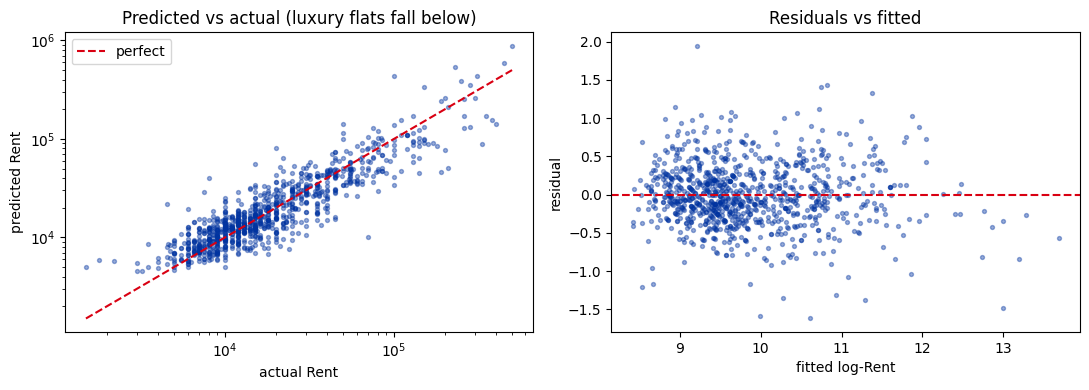

In [7]:
ARM_RED, ARM_BLUE = "#D90012", "#0033A0"
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(yraw_te, p_raw, s=8, alpha=0.4, color=ARM_BLUE)
lim = [yraw_te.min(), yraw_te.max()]
ax[0].plot(lim, lim, "--", color=ARM_RED, lw=1.5, label="perfect")
ax[0].set(xscale="log", yscale="log", xlabel="actual Rent", ylabel="predicted Rent",
          title="Predicted vs actual (luxury flats fall below)")
ax[0].legend()
ax[1].scatter(p_log, ylog_te - p_log, s=8, alpha=0.4, color=ARM_BLUE)
ax[1].axhline(0, ls="--", color=ARM_RED, lw=1.5)
ax[1].set(xlabel="fitted log-Rent", ylabel="residual", title="Residuals vs fitted")
plt.tight_layout(); plt.show()

In [8]:
print("=" * 54)
print(" MODEL CARD - Rent predictor (honest)")
print("=" * 54)
print(f" Data        : House_Rent_Dataset.csv (n={len(df)}), target log1p(Rent)")
print(f" Model       : Ridge(alpha={best:g}), scaled numerics + OHE(drop=first), seed {SEED}")
print(f" Selection   : 5-fold CV on train; test evaluated ONCE")
print(f" Baseline    : DummyRegressor R2(log) = {dummy_cv:.3f}")
print(f" Test scores : log-R2 = {logR2:.3f}   MAE = {mae:,.0f}   MedAE = {medae:,.0f}   RMSE = {rmse:,.0f}")
print(f" Headline    : typical error (MedAE) ~ {medae:,.0f} rent units")
print(" Failure mode: under-predicts luxury flats (>=100k); RMSE tail-dominated")
print("=" * 54)

 MODEL CARD - Rent predictor (honest)
 Data        : House_Rent_Dataset.csv (n=4746), target log1p(Rent)
 Model       : Ridge(alpha=1), scaled numerics + OHE(drop=first), seed 509
 Selection   : 5-fold CV on train; test evaluated ONCE
 Baseline    : DummyRegressor R2(log) = -0.001
 Test scores : log-R2 = 0.799   MAE = 11,364   MedAE = 3,639   RMSE = 31,807
 Headline    : typical error (MedAE) ~ 3,639 rent units
 Failure mode: under-predicts luxury flats (>=100k); RMSE tail-dominated


## Conclusion

After fixing all twelve bugs, the honest sealed-test **log-R² is ~0.80** - below the
teammate's contaminated, in-sample number, far above the dummy baseline (~0). The
model is good for typical flats and under-predicts luxury ones.

The lesson: **most of the twelve bugs never moved the headline number.** The leak and
the log-units/in-sample reporting did; the rest printed a respectable R² while being
wrong. Audit the *code* against the rules, not the score.

**Bonus directions:** nested CV; target-encode `Area Locality` correctly inside CV
folds; permutation importance; a P10-P90 prediction interval; per-city errors.